In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Function to reduce the size of the Datasets
def reduce_size(dataset):
  df = pd.read_csv(dataset)
  df_short = df[(df['hours'] > 5)]
  return df_short,df.size,df_short.size

In [ ]:
#Reducing size of datasets month wise
new_info = {"Datasets":['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'],'actual_size':[],'new_size':[]}
datasets = []
for i in range(1,13):
  if i < 10:
    df,a,b = reduce_size(f'/content/drive/MyDrive/datasets/sem_project/fleet-monthly-csvs-10-v3-2024-0{i}-01.csv')
    new_info['actual_size'].append(a)
    new_info['new_size'].append(b)
    df.to_csv(f'/content/drive/MyDrive/datasets/sem_project/fleet_{i}.csv',index=False)
  else:
    df,a,b = reduce_size(f'/content/drive/MyDrive/datasets/sem_project/fleet-monthly-csvs-10-v3-2024-{i}-01.csv')
    new_info['actual_size'].append(a)
    new_info['new_size'].append(b)
    df.to_csv(f'/content/drive/MyDrive/datasets/sem_project/fleet_{i}.csv',index=False)
  datasets.append(f'fleet_{i}.csv')

In [ ]:
new_info = pd.DataFrame(new_info)
new_info


,Datasets,actual_size,new_size
0,Jan,10809180,2584410
1,Feb,10234790,2392400
2,Mar,11585910,2927280
3,Apr,12173430,3006070
4,May,12364150,2617820
5,June,11736540,2554870
6,July,11588110,2575740
7,Aug,11942440,2895380
8,Sep,11774360,2959720
9,Oct,11918780,2967810


<Axes: xlabel='Datasets'>

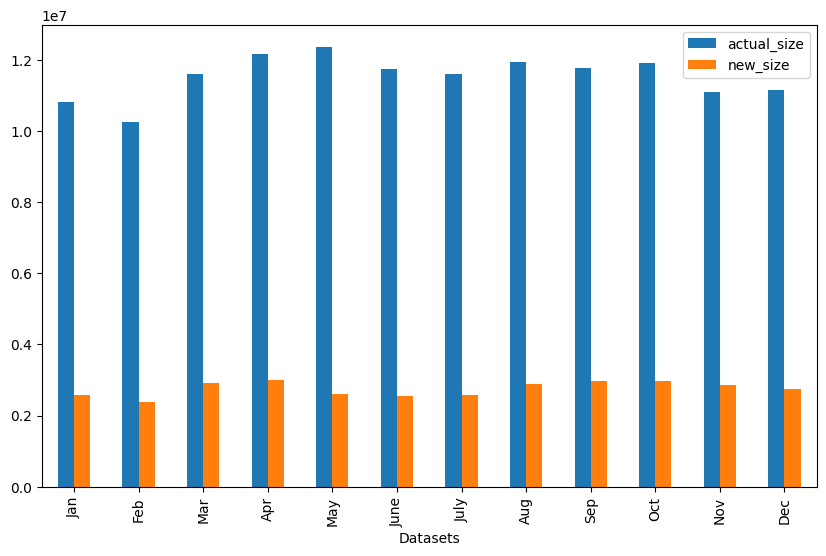

In [ ]:
new_info.plot(x='Datasets',y=['actual_size','new_size'],kind='bar',figsize=(10,6))

In [ ]:
#Funtions  to combine all datasets into Master datasets
def combine_datasets(datasets):
  df_list = []
  for i in range(len(datasets)):
    df = pd.read_csv(f'/content/drive/MyDrive/datasets/sem_project/{datasets[i]}')
    df_list.append(df)
  combined_dataset = pd.concat(df_list,ignore_index=True)
  return combined_dataset




In [ ]:
final_df = combine_datasets(datasets)

In [ ]:
final_df.head()

,date,year,month,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present
0,2024-01-01,2024,1,4.1,100.0,AFG,trawlers,22.9463,22.7075,1
1,2024-01-01,2024,1,4.2,100.0,AFG,trawlers,29.7680,29.7161,1
2,2024-01-01,2024,1,4.3,99.9,AFG,trawlers,6.4155,6.4155,1
3,2024-01-01,2024,1,4.4,99.9,AFG,trawlers,7.3788,6.7413,1
4,2024-01-01,2024,1,23.5,117.7,AFG,fishing,15.8074,6.7811,1


In [ ]:
print("Actual Combined Size : ",sum(new_info['actual_size']))
print("Reduced Combined Size : ",final_df.size)

Actual Combined Size :  138386190
Reduced Combined Size :  36410165


In [ ]:
final_df.drop(['date','year'],axis=1,inplace=True)
final_df['loitering_time'] = (final_df['hours'] - final_df['fishing_hours'])
final_df['loiter_ratio'] = (final_df['loitering_time']/final_df['hours']).round(4)
final_df['loitering'] = (final_df['loiter_ratio'] > 0.5).astype(int)
final_df.rename(columns={'cell_ll_lat':'lat','cell_ll_lon':'lon'},inplace=True)


In [ ]:
final_df.head()

,month,lat,lon,flag,geartype,hours,fishing_hours,mmsi_present,loitering_time,loiter_ratio,loitering
0,1,4.1,100.0,AFG,trawlers,22.9463,22.7075,1,0.2388,0.0104,0
1,1,4.2,100.0,AFG,trawlers,29.7680,29.7161,1,0.0519,0.0017,0
2,1,4.3,99.9,AFG,trawlers,6.4155,6.4155,1,0.0000,0.0000,0
3,1,4.4,99.9,AFG,trawlers,7.3788,6.7413,1,0.6375,0.0864,0
4,1,23.5,117.7,AFG,fishing,15.8074,6.7811,1,9.0263,0.5710,1


In [ ]:
final_df.to_csv('/content/drive/MyDrive/datasets/sem_project/combined_dataset.csv',index=False)